# Machine Learning Pipeline

In this notebook, I will build a machine learning pipeline to predict diabetes using the cleaned BRFSS 2024 dataset.

The pipeline will include:
- Splitting the data into training and testing sets
- Handling missing values
- Scaling numerical features
- Training classification models
- Evaluating model performance using appropriate metrics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

df = pd.read_csv("../data/brfss_diabetes_cleaned.csv")

print("Data loaded successfully!")
print("Shape:", df.shape)

df.head()

Data loaded successfully!
Shape: (453241, 14)


,Diabetes_012,BMI,GeneralHealth,PhysicalHealthDays,MentalHealthDays,Stroke,HeartDisease,Smoker,PhysicalActivity,Sex,Age,Education,Income,HeavyAlcohol
0,0.0,22.49,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,12.0,2.0,NaN,0.0
1,0.0,25.83,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,13.0,4.0,7.0,0.0
2,0.0,22.53,1.0,30.0,0.0,0.0,0.0,1.0,1.0,1.0,8.0,3.0,NaN,0.0
3,0.0,25.09,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,13.0,4.0,4.0,0.0
4,0.0,19.77,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,3.0,2.0,0.0


In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nTarget distribution:")
print(df["Diabetes_012"].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

Columns:
['Diabetes_012', 'BMI', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'Stroke', 'HeartDisease', 'Smoker', 'PhysicalActivity', 'Sex', 'Age', 'Education', 'Income', 'HeavyAlcohol']

Target distribution:
Diabetes_012
0.0    387432
1.0     65809
Name: count, dtype: int64

Missing values:
Income                86328
HeavyAlcohol          46099
BMI                   42248
Smoker                31564
PhysicalHealthDays    10843
MentalHealthDays       7968
HeartDisease           4913
Education              2240
Stroke                 1245
GeneralHealth          1242
PhysicalActivity       1234
Diabetes_012              0
Sex                       0
Age                       0
dtype: int64


## Train/Test Split

In this step, I will separate the dataset into features `X` and target `y`, then split the data into training and testing sets.

The split will use stratification to preserve the same diabetes class distribution in both training and testing data.


In [5]:
X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (453241, 13)
y shape: (453241,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (362592, 13)
X_test shape: (90649, 13)
y_train shape: (362592,)
y_test shape: (90649,)


In [8]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
Diabetes_012
0.0    85.480375
1.0    14.519625
Name: proportion, dtype: float64

Testing target distribution:
Diabetes_012
0.0    85.480259
1.0    14.519741
Name: proportion, dtype: float64


## Preprocessing Pipeline

In this step, I will create a preprocessing pipeline to handle missing values and scale the numerical features.

The preprocessing pipeline includes:
- `SimpleImputer` to fill missing values using the median.
- `StandardScaler` to scale the features for models such as Logistic Regression.

In [9]:
numeric_features = X_train.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

print("Numeric features:")
print(numeric_features)

print("\nNumber of features:", len(numeric_features))

Numeric features:
['BMI', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'Stroke', 'HeartDisease', 'Smoker', 'PhysicalActivity', 'Sex', 'Age', 'Education', 'Income', 'HeavyAlcohol']

Number of features: 13


In [10]:
X_train_processed = preprocessor.fit_transform(X_train)

print("Processed X_train shape:", X_train_processed.shape)
print("Missing values after preprocessing:", np.isnan(X_train_processed).sum())

Processed X_train shape: (362592, 13)
Missing values after preprocessing: 0


## Logistic Regression Model

In this step, I will build the first full machine learning pipeline using Logistic Regression.

The pipeline includes preprocessing and model training in one structure.

In [11]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

print(logistic_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['BMI', 'GeneralHealth',
                                                   'PhysicalHealthDays',
                                                   'MentalHealthDays', 'Stroke',
                                                   'HeartDisease', 'Smoker',
                                                   'PhysicalActivity', 'Sex',
                                                   'Age', 'Education', 'Income',
                                                   'HeavyAlcohol'])])),
                ('model',
  

In [12]:
logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [13]:
y_pred_logistic = logistic_pipeline.predict(X_test)
y_pred_proba_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Prediction completed!")
print("Predictions shape:", y_pred_logistic.shape)
print("Probabilities shape:", y_pred_proba_logistic.shape)

Prediction completed!
Predictions shape: (90649,)
Probabilities shape: (90649,)


## Logistic Regression Evaluation

In this step, I will evaluate the Logistic Regression model using multiple metrics because the target variable is imbalanced.

The metrics include:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

In [14]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)
logistic_roc_auc = roc_auc_score(y_test, y_pred_proba_logistic)

print("Logistic Regression Evaluation:")
print("Accuracy:", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall:", round(logistic_recall, 4))
print("F1-score:", round(logistic_f1, 4))
print("ROC-AUC:", round(logistic_roc_auc, 4))

Logistic Regression Evaluation:
Accuracy: 0.7013
Precision: 0.2868
Recall: 0.7111
F1-score: 0.4087
ROC-AUC: 0.777


In [16]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

         0.0       0.93      0.70      0.80     77487
         1.0       0.29      0.71      0.41     13162

    accuracy                           0.70     90649
   macro avg       0.61      0.71      0.60     90649
weighted avg       0.84      0.70      0.74     90649



In [17]:
logistic_cm = confusion_matrix(y_test, y_pred_logistic)

print(logistic_cm)

[[54211 23276]
 [ 3803  9359]]


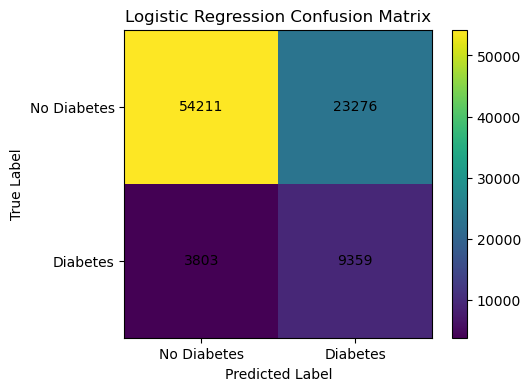

In [18]:
plt.figure(figsize=(5, 4))

plt.imshow(logistic_cm)
plt.colorbar()

plt.xticks(ticks=[0, 1], labels=["No Diabetes", "Diabetes"])
plt.yticks(ticks=[0, 1], labels=["No Diabetes", "Diabetes"])

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(logistic_cm.shape[0]):
    for j in range(logistic_cm.shape[1]):
        plt.text(j, i, logistic_cm[i, j], ha="center", va="center")

plt.show()

#### Logistic Regression Insight

The Logistic Regression model achieved an accuracy of about 70.13% and a ROC-AUC score of about 0.777.

Because the dataset is imbalanced, accuracy alone is not enough to judge the model. The recall for the diabetes class is about 71%, which means the model was able to detect a good portion of diabetic respondents.

However, the precision for the diabetes class is relatively low, about 29%. This means the model predicted many false positives for diabetes.

This behavior is expected because `class_weight="balanced"` was used to help the model pay more attention to the minority diabetes class. In a healthcare-related problem, higher recall can be useful because missing diabetic cases may be more serious than producing some false positives.

## Random Forest Model

In this step, I will build a second machine learning pipeline using Random Forest.

Random Forest can capture non-linear relationships between features and the target variable. I will use a limited `max_depth` to reduce training time and avoid overfitting.

In [19]:
random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

print(random_forest_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['BMI', 'GeneralHealth',
                                                   'PhysicalHealthDays',
                                                   'MentalHealthDays', 'Stroke',
                                                   'HeartDisease', 'Smoker',
                                                   'PhysicalActivity', 'Sex',
                                                   'Age', 'Education', 'Income',
                                                   'HeavyAlcohol'])])),
                ('model',
  

In [20]:
random_forest_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [21]:
y_pred_rf = random_forest_pipeline.predict(X_test)
y_pred_proba_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Prediction completed!")
print("Predictions shape:", y_pred_rf.shape)
print("Probabilities shape:", y_pred_proba_rf.shape)

Prediction completed!
Predictions shape: (90649,)
Probabilities shape: (90649,)


## Random Forest Evaluation

In this step, I will evaluate the Random Forest model using the same evaluation metrics used for Logistic Regression.

This allows a fair comparison between the two models.

In [22]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print("Random Forest Evaluation:")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1-score:", round(rf_f1, 4))
print("ROC-AUC:", round(rf_roc_auc, 4))

Random Forest Evaluation:
Accuracy: 0.7009
Precision: 0.2888
Recall: 0.7247
F1-score: 0.413
ROC-AUC: 0.7853


In [23]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.94      0.70      0.80     77487
         1.0       0.29      0.72      0.41     13162

    accuracy                           0.70     90649
   macro avg       0.61      0.71      0.61     90649
weighted avg       0.84      0.70      0.74     90649



In [24]:
rf_cm = confusion_matrix(y_test, y_pred_rf)

print(rf_cm)

[[53997 23490]
 [ 3623  9539]]


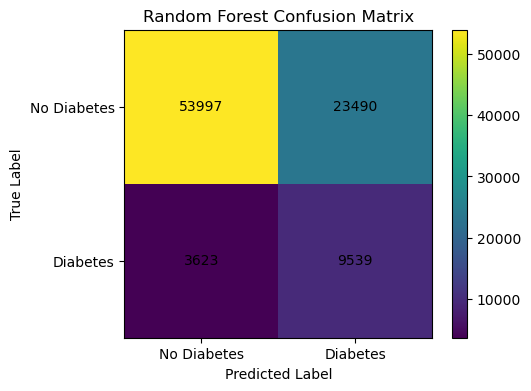

In [25]:
plt.figure(figsize=(5, 4))

plt.imshow(rf_cm)
plt.colorbar()

plt.xticks(ticks=[0, 1], labels=["No Diabetes", "Diabetes"])
plt.yticks(ticks=[0, 1], labels=["No Diabetes", "Diabetes"])

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(rf_cm.shape[0]):
    for j in range(rf_cm.shape[1]):
        plt.text(j, i, rf_cm[i, j], ha="center", va="center")

plt.show()

#### Random Forest Insight

The Random Forest model achieved an accuracy of about 70.09% and a ROC-AUC score of about 0.7853.

Compared to Logistic Regression, Random Forest achieved slightly better recall, F1-score, and ROC-AUC. The recall for the diabetes class is about 72.47%, which means the model detected a larger portion of diabetic respondents.

However, the precision is still relatively low, about 28.88%, meaning the model still produces many false positive diabetes predictions.

Overall, Random Forest performs slightly better than Logistic Regression for this dataset, especially in detecting diabetic cases.

## Model Comparison

In this step, I will compare the performance of Logistic Regression and Random Forest using the main evaluation metrics.

In [26]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logistic_accuracy, rf_accuracy],
    "Precision": [logistic_precision, rf_precision],
    "Recall": [logistic_recall, rf_recall],
    "F1-score": [logistic_f1, rf_f1],
    "ROC-AUC": [logistic_roc_auc, rf_roc_auc]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.701276,0.286778,0.711062,0.408717,0.777010
1,Random Forest,0.700901,0.288807,0.724738,0.413024,0.785292


In [27]:
model_comparison_rounded = model_comparison.copy()

numeric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

model_comparison_rounded[numeric_cols] = model_comparison_rounded[numeric_cols].round(4)

model_comparison_rounded

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7013,0.2868,0.7111,0.4087,0.7770
1,Random Forest,0.7009,0.2888,0.7247,0.4130,0.7853


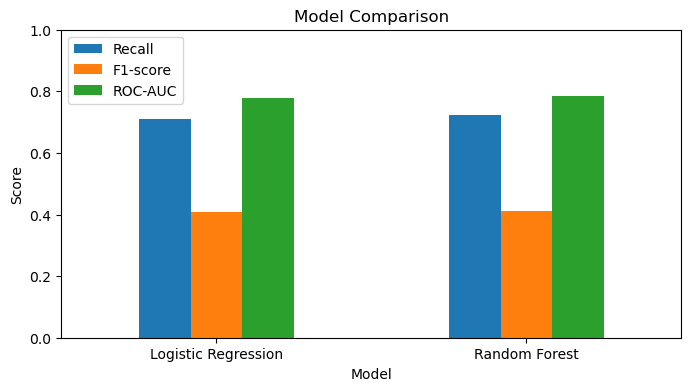

In [28]:
model_comparison_rounded.set_index("Model")[["Recall", "F1-score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.show()

#### Model Comparison Insight

The comparison shows that Random Forest performs slightly better than Logistic Regression on the most important metrics for this imbalanced classification problem.

Although Logistic Regression has a slightly higher accuracy, Random Forest achieves better precision, recall, F1-score, and ROC-AUC.

Since the diabetes class is the minority class, recall and F1-score are more important than accuracy alone. Random Forest detects more diabetic cases and has a slightly better overall balance between recall and precision.

Therefore, Random Forest will be selected for the next steps, including cross-validation and hyperparameter tuning.

## Cross Validation

In this step, I will apply cross-validation to the selected Random Forest model using the training data only.

Cross-validation gives a more reliable estimate of model performance by evaluating the model on multiple splits of the training data.

In [29]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [39]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [40]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Cross-validation completed successfully!")

Cross-validation completed successfully!


In [41]:
cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Mean Score": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Std Score": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

cv_summary[["Mean Score", "Std Score"]] = cv_summary[["Mean Score", "Std Score"]].round(4)

cv_summary

,Metric,Mean Score,Std Score
0,Accuracy,0.7036,0.0023
1,Precision,0.2906,0.0014
2,Recall,0.7228,0.0056
3,F1-score,0.4146,0.0015
4,ROC-AUC,0.7860,0.0013


#### Cross Validation Insight

The 5-fold stratified cross-validation results show that the Random Forest model has stable performance across different training splits.

The model achieved an average ROC-AUC score of about 0.7860 and an average recall of about 0.7228. This means the model can detect a good portion of diabetic respondents while maintaining consistent performance across folds.

The low standard deviation values indicate that the model performance does not change much between folds, which suggests that the model is relatively stable.

Since this is an imbalanced healthcare-related classification problem, recall and ROC-AUC are more important than accuracy alone.

## Hyperparameter Tuning

In this step, I will tune the Random Forest model using RandomizedSearchCV.

Because Random Forest has several hyperparameters and the dataset is large, RandomizedSearchCV is more practical than trying every possible combination with GridSearchCV.

The tuning will optimize ROC-AUC because this metric is useful for imbalanced classification problems and evaluates how well the model separates diabetic and non-diabetic respondents.

In [47]:
from sklearn.model_selection import RandomizedSearchCV
param_distributions = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [8, 10, 12, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}
tuning_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)
random_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="roc_auc",
    cv=tuning_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("RandomizedSearchCV is ready!")

RandomizedSearchCV is ready!


In [48]:
random_search.fit(X_train, y_train)

print("Hyperparameter tuning completed successfully!")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Hyperparameter tuning completed successfully!


In [49]:
print("Best parameters:")
print(random_search.best_params_)

print("\nBest ROC-AUC score:")
print(round(random_search.best_score_, 4))

Best parameters:
{'model__n_estimators': 150, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 12}

Best ROC-AUC score:
0.7868


In [50]:
best_rf_pipeline = random_search.best_estimator_

print("Best Random Forest pipeline saved successfully!")

Best Random Forest pipeline saved successfully!


## Tuned Random Forest Evaluation

In this step, I will evaluate the best Random Forest model from hyperparameter tuning on the test set.

In [51]:
y_pred_best_rf = best_rf_pipeline.predict(X_test)
y_pred_proba_best_rf = best_rf_pipeline.predict_proba(X_test)[:, 1]

print("Best Random Forest prediction completed!")
print("Predictions shape:", y_pred_best_rf.shape)
print("Probabilities shape:", y_pred_proba_best_rf.shape)

Best Random Forest prediction completed!
Predictions shape: (90649,)
Probabilities shape: (90649,)


In [52]:
best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)
best_rf_precision = precision_score(y_test, y_pred_best_rf)
best_rf_recall = recall_score(y_test, y_pred_best_rf)
best_rf_f1 = f1_score(y_test, y_pred_best_rf)
best_rf_roc_auc = roc_auc_score(y_test, y_pred_proba_best_rf)

print("Tuned Random Forest Evaluation:")
print("Accuracy:", round(best_rf_accuracy, 4))
print("Precision:", round(best_rf_precision, 4))
print("Recall:", round(best_rf_recall, 4))
print("F1-score:", round(best_rf_f1, 4))
print("ROC-AUC:", round(best_rf_roc_auc, 4))

Tuned Random Forest Evaluation:
Accuracy: 0.7004
Precision: 0.2891
Recall: 0.7291
F1-score: 0.414
ROC-AUC: 0.7866


In [53]:
print(classification_report(y_test, y_pred_best_rf))

              precision    recall  f1-score   support

         0.0       0.94      0.70      0.80     77487
         1.0       0.29      0.73      0.41     13162

    accuracy                           0.70     90649
   macro avg       0.61      0.71      0.61     90649
weighted avg       0.84      0.70      0.74     90649



In [54]:
best_rf_cm = confusion_matrix(y_test, y_pred_best_rf)

print(best_rf_cm)

[[53892 23595]
 [ 3566  9596]]


#### Tuned Random Forest Insight

After hyperparameter tuning, the Random Forest model achieved a ROC-AUC score of about 0.7866 and a recall of about 72.91% for the diabetes class.

Compared to the original Random Forest model, the tuned model slightly improved recall, F1-score, and ROC-AUC. This means the tuned model became slightly better at identifying diabetic respondents.

The precision is still relatively low, about 28.91%, meaning the model still produces many false positives. However, in a healthcare-related classification problem, higher recall can be more important because missing actual diabetic cases may be more serious than incorrectly flagging some non-diabetic cases.

Overall, the tuned Random Forest model is the best-performing model in this project so far and will be selected as the final model.

## Final Model Comparison

In this step, I will compare the three trained models:
- Logistic Regression
- Random Forest
- Tuned Random Forest

The final model will be selected based on recall, F1-score, and ROC-AUC because the dataset is imbalanced.

In [55]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        best_rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision,
        best_rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall,
        best_rf_recall
    ],
    "F1-score": [
        logistic_f1,
        rf_f1,
        best_rf_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc,
        best_rf_roc_auc
    ]
})

final_model_comparison_rounded = final_model_comparison.copy()

numeric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

final_model_comparison_rounded[numeric_cols] = final_model_comparison_rounded[numeric_cols].round(4)

final_model_comparison_rounded

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7013,0.2868,0.7111,0.4087,0.7770
1,Random Forest,0.7009,0.2888,0.7247,0.4130,0.7853
2,Tuned Random Forest,0.7004,0.2891,0.7291,0.4140,0.7866


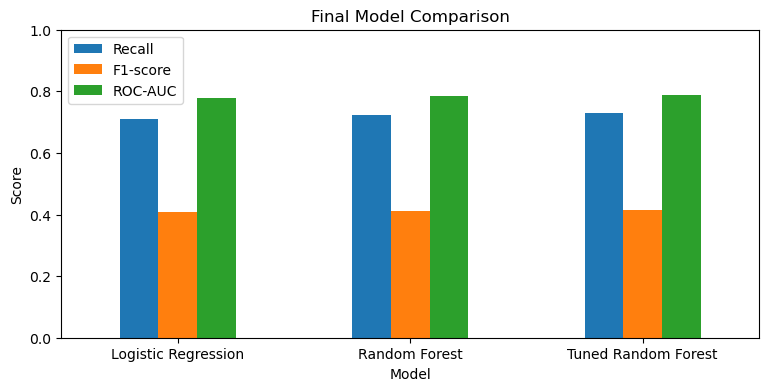

In [56]:
final_model_comparison_rounded.set_index("Model")[["Recall", "F1-score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(9, 4)
)

plt.title("Final Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.show()

#### Final Model Selection

The Tuned Random Forest model was selected as the final model.

It achieved the best recall and ROC-AUC score among the tested models. Although the improvement after tuning was small, the tuned model performed slightly better at detecting diabetic respondents.

Since this is an imbalanced healthcare-related classification problem, recall is especially important because missing actual diabetic cases may be more serious than producing false positives.

Therefore, the Tuned Random Forest pipeline will be saved and used for deployment.

In [57]:
import os
import joblib

# Create models folder if it does not exist
os.makedirs("../models", exist_ok=True)

# Save the final tuned Random Forest pipeline
model_path = "../models/diabetes_rf_pipeline.pkl"

joblib.dump(best_rf_pipeline, model_path)

print("Final model saved successfully!")
print("Model path:", model_path)

Final model saved successfully!
Model path: ../models/diabetes_rf_pipeline.pkl


In [59]:
print(os.path.exists("../models/diabetes_rf_pipeline.pkl"))

True
